# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [1]:
expectations_text = """ЗДЕСЬ НАПИШИТЕ СВОИ ОЖИДАНИЯ ОТ ЭКСПЕРИМЕНТОВ ПО LR И ОПТИМИЗАТОРАМ.
Можно честно написать, что именно вам кажется очевидным, а что — не до конца понятным,
чтобы потом сравнить с реальными кривыми.

1. Я думаю, что при очень маленьком lr время сходимости, как и точность значительно увеличатся, а loss, скорее всего, уменьшится. Тогда для достижения желаемой точности следует увеличить количество эпох.
2. При слишком большом lr могут появиться большие изломы в кривых, они уже не будут плавными, потому что модель обучается большими шагами.
3. Мне кажется, что по скорости сходимости SGD, SGD с momentum и Adam увеличиваются соответственно. Рывки на графиках будут у Adam, т.к. он самый быстрый, меньше всего будет у SGD. По чувствительности к lr пока не могу сказать."""
print(expectations_text)

ЗДЕСЬ НАПИШИТЕ СВОИ ОЖИДАНИЯ ОТ ЭКСПЕРИМЕНТОВ ПО LR И ОПТИМИЗАТОРАМ.
Можно честно написать, что именно вам кажется очевидным, а что — не до конца понятным,
чтобы потом сравнить с реальными кривыми.


## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 0
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 0


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [2]:
batch_size = 256  # TODO: поменять и прокомментировать выбор в выводах

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 256


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


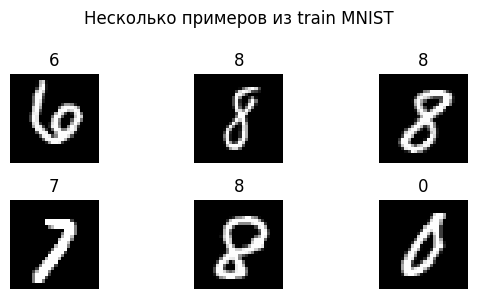

In [3]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [5]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [6]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [13]:
num_epochs = 10  # учитывайте время обучения

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. TODO: предложите свой вариант
h_adam_big = run_experiment(
    config_name="Adam lr=0.5",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_adam_big)
labels.append("Adam 0.5")


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/10 | train_loss=2.2843, train_acc=0.2072, test_loss=2.2484, test_acc=0.2900
Эпоха 2/10 | train_loss=2.2144, train_acc=0.3589, test_loss=2.1728, test_acc=0.4485
Эпоха 3/10 | train_loss=2.1315, train_acc=0.5014, test_loss=2.0774, test_acc=0.5715
Эпоха 4/10 | train_loss=2.0226, train_acc=0.6010, test_loss=1.9492, test_acc=0.6453
Эпоха 5/10 | train_loss=1.8772, train_acc=0.6576, test_loss=1.7815, test_acc=0.6888
Эпоха 6/10 | train_loss=1.6948, train_acc=0.6987, test_loss=1.5811, test_acc=0.7236
Эпоха 7/10 | train_loss=1.4902, train_acc=0.7287, test_loss=1.3710, test_acc=0.7538
Эпоха 8/10 | train_loss=1.2891, train_acc=0.7599, test_loss=1.1784, test_acc=0.7789
Эпоха 9/10 | train_loss=1.1141, train_acc=0.7825, test_loss=1.0192, test_acc=0.8005
Эпоха 10/10 | train_loss=0.9732, train_acc=0.8033, test_loss=0.8949, test_acc=0.8169

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/10 | train_loss=1.6957, train_acc=0.6312, test_loss=0.8981, test_acc=0.8170
Эпох

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


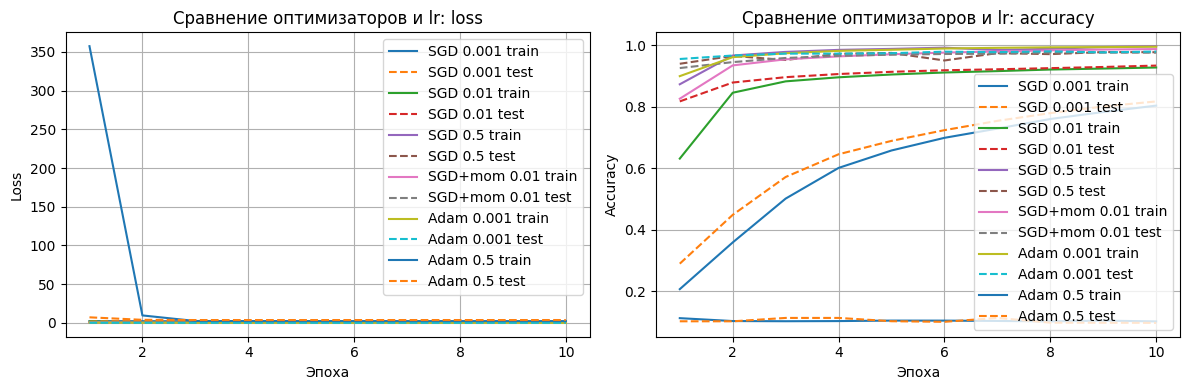

In [14]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [ ]:
analysis_text = """ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ АНАЛИЗ ВАШИХ КРИВЫХ.
Сравните поведение всех конфигураций. Не стесняйтесь писать:
"вот здесь я ожидал одно, но увидел другое" — это нормальная часть обучения.
Старайтесь использовать конкретные числа и фразы вроде
"для SGD 0.5 test accuracy колеблется около ...

Каждой конфигурации я дал по 10 эпох.
1. У SGD с lr=0.001 точность росла медленнее остальных. На графике видно, что ей нужно еще около 8-10 эпох, чтобы достичь желаемой точности. За 10 эпох она вышла в test_acc = 0.8167. Даже не 0.85. Хотя тестовая точность оказалась больше, чем обучающая.
2. У SGD c lr=0.5 тестовой части были заметные скачки loss на 3-ей и 8-ой эпохе, и на 10-ой эпохе уже был виден подъём. Train_loss плавно идет вниз. На test_acc также есть скачки, только вниз, а train_acc плавно растет. В итоге test_acc=0.0.9694.
3. Я бы не назвал SGD с lr=0.01 рабочим компромиссом, потому что скорость тут всё же медленная. Итоговая test_acc=0.9327. Несмотря на стабильность этой конфигурации, мне кажется, что есть варианты лучше.
4. Momentum дал свой заметный прирост к скорости обучения. По сравнению с чистым SGD точность стала выше за те же 10 эпох: у чистого SGD test_acc=0.9327, а у SGD+mom test_acc=0.9776. Начальный скачок у обоих был в начальные эпохи, но у SGD+mom он плавнее.
5. Adam быстрее всех вышел на высокую точность. Уже на 2-ой эпохе у него было test_acc=0.9660, а конечная = 0.9789 (что выше остальных). Были совсем небольшие скачки test_loss на 7-ой и 9-ой эпохе, хотя train_loss стабильно падал (можно ли это вообще считать переобучением? Думаю, что нет)""" 
print(analysis_text)

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [ ]:
final_conclusion = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ.
Представьте, что через полгода вы откроете этот ноутбук и захотите
вспомнить, как выбирать lr и оптимизатор. Напишите так, чтобы будущему вам
было понятно, что именно вы поняли на этой лабораторной.

Выбрал batch_size = 256, потому что по тестам в ЛР5 это один из оптимальных и эстетичных вариантов с меньшим временем сходимости и приемлемым объемом памяти для cpu.
Слишком маленьким диапазоном lr для SGD будет от 0.001 и ниже, а большим от 0.4 и выше.
Думаю, что SGD+mom стоит использовать, когда идет гонка за скорость обучения. Хотя в нынешних реалиях, когда всегда хочется, чтобы всё быстро работало, стоит его использовать всегда.
Не знаю, дает ли большую нагрузку momentum на систему, чем чистый SGD, но если да, то для задач с ограниченными возможностями стоит использовать чистый SGD.
Лично для своей работы я бы использовал Adam, т.к. он самый быстрый из тестируемых, но в нем важно подобрать правильный шаг, потому что я взял Adam lr=0.5 и там test_acc=0.0977 (даже 10% нет).
Например, если брать SGD с lr=0.5, то там test_acc=0.9767 за то же время. Adam больше к душе лежит, на имя похоже, его бы использовал.
"""
print(final_conclusion)